In [ ]:
import random
import torch
import matplotlib.pyplot as plt

In [ ]:
def synthetic_data(w, b, num_examples):
    """Veri yaratma, y = Xw + b + gürültü."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('oznitelikler:', features[0],'\netiket:', labels[0])


oznitelikler: tensor([-2.0591, -0.4210]) 
etiket: tensor([1.5043])


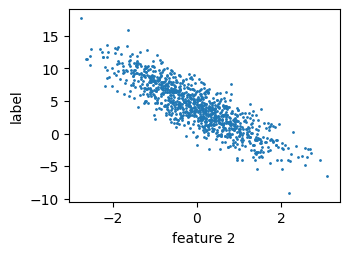

In [ ]:
plt.figure(figsize=(3.5, 2.5))
plt.scatter(features[:, 1].detach().numpy(),
            labels.detach().numpy(),
            s=1)
plt.xlabel("feature 2")
plt.ylabel("label")
plt.show()

In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # Örnekler belirli bir sıra gözetmeksizin rastgele okunur
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [ ]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.4884,  1.5366],
        [-0.4082, -0.4680],
        [ 0.0376, -0.3595],
        [-0.3793,  0.5492],
        [ 0.1919, -1.0727],
        [-0.6476, -0.1387],
        [ 0.0450,  1.3970],
        [-0.4134,  0.6249],
        [-1.1450,  0.8601],
        [ 0.9221, -1.3474]]) 
 tensor([[-2.0184],
        [ 4.9937],
        [ 5.5036],
        [ 1.5682],
        [ 8.2270],
        [ 3.3755],
        [-0.4584],
        [ 1.2467],
        [-1.0007],
        [10.6192]])


In [ ]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [ ]:
def linreg(X, w, b):
    """Doğrusal regresyon modeli."""
    return torch.matmul(X, w) + b

In [ ]:
def squared_loss(y_hat, y):
    """Kare kayıp."""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [ ]:
def sgd(params, lr, batch_size):
    """Minigrup rasgele gradyan inişi."""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [ ]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # `X` ve `y`'deki minigrup kaybı

        # [`w`, `b`]'e göre `l` üzerindeki gradyanı hesaplayın
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # Parametreleri gradyanlarına göre güncelle
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000049
epoch 2, loss 0.000049
epoch 3, loss 0.000049


In [ ]:
print(f'w tahminindeki hata: {true_w - w.reshape(true_w.shape)}')
print(f'b tahminindeki hata: {true_b - b}')

w tahminindeki hata: tensor([ 5.1594e-04, -5.7936e-05], grad_fn=<SubBackward0>)
b tahminindeki hata: tensor([0.0004], grad_fn=<RsubBackward1>)
